In [1]:
%matplotlib widget

In [2]:
import numpy as np
import pygimli as pg
import empymod as ep
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, 'src')

from FDEM1D import FDEM1D, FDEM1DModelling, LCModelling
from showStitched import showStitchedModels

In [3]:
# First step: check configuration of FDEM to perform forward
# Second step: check number of layers in FDEM1D Modelling forward class

In [240]:
## Create a test model

pos = 10
nLayers = 3

x =  np.linspace(0,pos,pos, endpoint=False)
sigm_1 = 50/1000
sigm_2 = 800/1000
sigm_3 = 50/1000
sigm_4 = 100/1000
thk_1 = x/9 + 1 #np.sin(np.pi/2*x/3) + 2
thk_2 = 4 - thk_1 # 1/9*x + 1.5
thk_3 = np.ones_like(x)*2

models = np.zeros((pos, nLayers*2-1))
models[:,0] = thk_1
models[:,1] = thk_2
#models[:,2] = thk_3
models[:,2] = sigm_1
models[:,3] = sigm_2
models[:,4] = sigm_3
#models[:,6] = sigm_4

nSoundings = pos

## Create test data

data_t = []

# 3 lay case
for p in range(pos):
    data_t.append(FDEM1D(models[p,2:], models[p,:2]))

# 4 lay case
#for p in range(pos):
#    data_t.append(FDEM1D(models[p,3:], models[p,:3]))

<AxesSubplot:title={'center':'True Model'}>

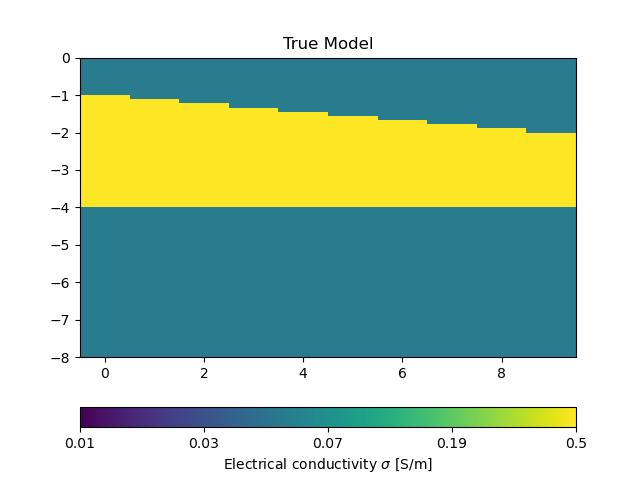

In [241]:
inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]',
         'cMin': 10/1000,
         'cMax': 500/1000}

showStitchedModels(models, zMax=8, title = 'True Model', **inputs)

# LCI

In [314]:
LC = LCModelling(FDEM1DModelling)

Inversion is normalized


In [315]:
LC.initJacobian(dataVals=data_t, nLay=nLayers)
LC.createJacobian(models)
LC.constraint_matrix(data_t, nLay=nLayers)
LC.normalization(data_t, cWeight_1=0, cWeight_2=1, nLay=nLayers)
LC.createWeight(data_t, cWeight_1=0, cWeight_2=1, nLay=nLayers)
LC.createConstraints()


Jacobian size: 162 45 180
only cWeight for resistivity
Constraint cWeight length: 45
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f7a3cd301d0>


In [316]:
RM = LC.regionManager()
RM.regionIdxs()

2 [1, 2]

# Inversion

In [317]:
# Initial model
m0 = models.copy()

# 3 lay case
m0[:,:2] = 2
m0[:,2:] = 500/1000

# 4 lay case
#m0[:,:3] = 2
#m0[:,3:] = 50/1000

In [318]:
# Define inversion
#LC.region(1).setConstraintType(10)
#LC.region(2).setConstraintType(10)

# Why is the behaviour so strange ??? when you change the limits
transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000,1000/1000)

LC.region(1).setTransModel(transThk)
LC.region(2).setTransModel(transSig)

inv.dataTrans = transData

inv = pg.Inversion(LC)
data_true = np.array(data_t).ravel()
relativeError = np.ones_like(data_true)*1e-3 # what is this for?

01/03/24 - 14:01:44 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


In [319]:
models_est = inv.run(data_true, relativeError, startModel=m0.ravel(), verbose=True, lam=1)

01/03/24 - 14:01:45 - pyGIMLi - INFO - Starting model set from given array. [2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5
 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.
 2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5]
01/03/24 - 14:01:45 - pyGIMLi - INFO - Starting inversion.
01/03/24 - 14:01:45 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


min/max(dweight) = 2665.08/1.26747e+06
fop: <FDEM1D.LCModelling object at 0x7f7a3a979220>
Data transformation: <pgcore._pygimli_.RTrans object at 0x7f7a3b17fa00>
Model transformation (cumulative):
	 0 <pgcore._pygimli_.RTransLogLU object at 0x7f7a3be129a0>
	 1 <pgcore._pygimli_.RTransLogLU object at 0x7f7a3d3cdcc0>
min/max (data): 7.9e-04/0.38
min/max (error): 0.1%/0.1%
min/max (start model): 0.5/2
--------------------------------------------------------------------------------
use model trans from RegionManager
min/max(dweight) = 2665.08/1.26747e+06
 found valid constraints matrix. omit rebuild
constraint matrix of size(nBounds x nModel) 45 x 50
calculating jacobian matrix (forced=1)...... 0.272 s
min data = 0.000788973 max data = 0.375223 (180)
min error = 0.001 max error = 0.001 (180)
min response = 0.00280598 max response = 0.38984 (180)
calc without reference model
0: rms/rrms(data, response) = 0.0471341/101.925%
0: chi^2(data, response, error, log) = 1.03888e+06
0: Phi = 1.86998e

<AxesSubplot:title={'center':'True Model LCI'}>

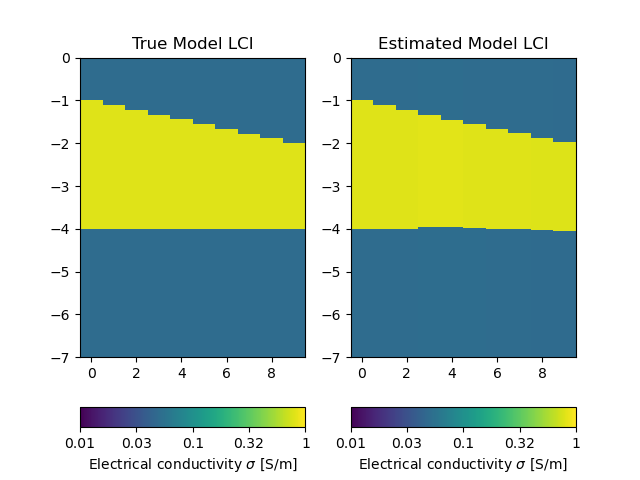

In [320]:
fig, ax = plt.subplots(1,2)

inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]',
         'cMin': 10/1000,
         'cMax': 1000/1000}

showStitchedModels(ax = ax[1], models=np.array(models_est).reshape(np.shape(models)), zMax=7, 
                  title = 'Estimated Model LCI', **inputs)

showStitchedModels(ax = ax[0], models=models, zMax=7, 
                  title = 'True Model LCI', **inputs)


In [321]:
data_est = inv.fop.response(models_est)

In [322]:
data_true = np.array(data_t).reshape(pos,2,3,3)

In [323]:
data_est = np.array(data_est).reshape(pos,2,3,3)

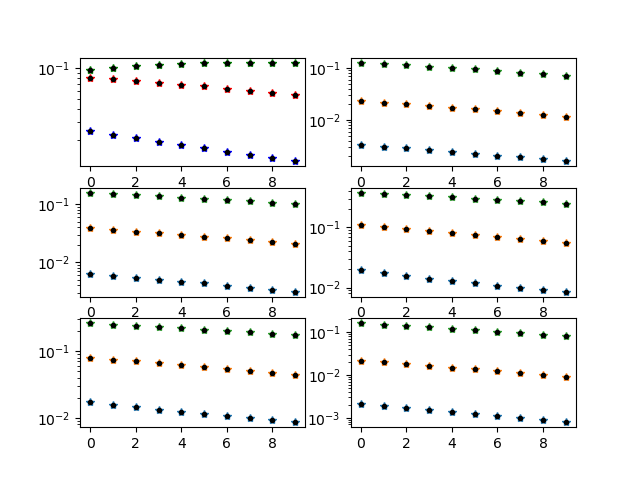

In [324]:
fig, ax = plt.subplots(3,2)

ax[0,0].semilogy(data_est[:,0,0,0], '*b', label = 'Q h 2m')
ax[0,0].semilogy(data_est[:,0,0,1], '*r', label = 'Q h 4m')
ax[0,0].semilogy(data_est[:,0,0,2], '*g', label = 'Q h 8m')
ax[0,0].semilogy(data_true[:,0,0,0], '.k', label = 'Q h 2m')
ax[0,0].semilogy(data_true[:,0,0,1], '.k', label = 'Q h 4m')
ax[0,0].semilogy(data_true[:,0,0,2], '.k', label = 'Q h 8m')

ax[0,1].semilogy(data_est[:,1,0,0], '*', label = 'IP h 2m')
ax[0,1].semilogy(data_est[:,1,0,1], '*', label = 'IP h 4m')
ax[0,1].semilogy(data_est[:,1,0,2], '*', label = 'IP h 8m')
ax[0,1].semilogy(data_true[:,1,0,0], '.k', label = 'IP h 2m')
ax[0,1].semilogy(data_true[:,1,0,1], '.k', label = 'IP h 4m')
ax[0,1].semilogy(data_true[:,1,0,2], '.k', label = 'IP h 8m')

ax[1,0].semilogy(data_est[:,0,1,0], '*', label = 'Q v 2m')
ax[1,0].semilogy(data_est[:,0,1,1], '*', label = 'Q v 4m')
ax[1,0].semilogy(data_est[:,0,1,2], '*', label = 'Q v 8m')
ax[1,0].semilogy(data_true[:,0,1,0], '.k', label = 'Q v 2m')
ax[1,0].semilogy(data_true[:,0,1,1], '.k', label = 'Q v 4m')
ax[1,0].semilogy(data_true[:,0,1,2], '.k', label = 'Q v 8m')

ax[1,1].semilogy(data_est[:,1,1,0], '*', label = 'IP v 2m')
ax[1,1].semilogy(data_est[:,1,1,1], '*', label = 'IP v 4m')
ax[1,1].semilogy(data_est[:,1,1,2], '*', label = 'IP v 8m')
ax[1,1].semilogy(data_true[:,1,1,0], '.k', label = 'IP v 2m')
ax[1,1].semilogy(data_true[:,1,1,1], '.k', label = 'IP v 4m')
ax[1,1].semilogy(data_true[:,1,1,2], '.k', label = 'IP v 8m')

ax[2,0].semilogy(data_est[:,0,2,0], '*', label = 'Q p 2m')
ax[2,0].semilogy(data_est[:,0,2,1], '*', label = 'Q p 4m')
ax[2,0].semilogy(data_est[:,0,2,2], '*', label = 'Q p 8m')
ax[2,0].semilogy(data_true[:,0,2,0], '.k', label = 'Q p 2m')
ax[2,0].semilogy(data_true[:,0,2,1], '.k', label = 'Q p 4m')
ax[2,0].semilogy(data_true[:,0,2,2], '.k', label = 'Q p 8m')

ax[2,1].semilogy(data_est[:,1,2,0], '*', label = 'IP p 2m')
ax[2,1].semilogy(data_est[:,1,2,1], '*', label = 'IP p 4m')
ax[2,1].semilogy(data_est[:,1,2,2], '*', label = 'IP p 8m')
ax[2,1].semilogy(data_true[:,1,2,0], '.k', label = 'IP p 2m')
ax[2,1].semilogy(data_true[:,1,2,1], '.k', label = 'IP p 4m')
ax[2,1].semilogy(data_true[:,1,2,2], '.k', label = 'IP p 8m')
